In [ ]:
# 목표: 순환 신경망에서 빼놓을 수 없는 핵심기술인 LSTM 과 GRU셀을 사용한 모델을 만들어 봅니다

# 핵심키워드 : LSTM, 셀 상태, GRU

# 핵심 패키지와 함수 : LSTM, GRU,

# 데이터셋 : IMDB 데이터 셋

# LSTM
LSTM (Long Short-Term Memory) : '단기기억'을 '오래' 기억하기

In [ ]:
# 순환신경망에서 빼놓을수 없는 핵심기술 LSTM 와 GRU셀 을 사용한 모델

# SimpleRNN 보다 훨~씬 계산이 복잡.  그러나 '성능'이 뛰어남! 순환신경망에서 많이 채택

# 일반적으로 기본 순환층은 '긴 시퀀스'를 학습하기 어렵다.
# 시퀀스가 길수록 순환되는 은닉상태에 담긴 정보가 희석되기 때문
# 따라서 멀리 떨어져 있는 단어 정보를 인식하는데 어려울수 있다.
# 이를 위해 LSTM 과 GRU셀이 등장!

# LSTM 구조

> ppt 참조

# IMDB 데이터 준비

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, random

import tensorflow as tf
from tensorflow import keras

def set_seed(seed = 42):
  tf.keras.utils.set_random_seed(seed)
  # tf.config.experimental.enable_op_determinism()

In [2]:
# 학습모델 저장해볼거다
base_path = r'/content/drive/MyDrive/KoreaIT (코리아it)/260113 💚AI MCP 에이전트 S1/[MCP_Agent]/dataset(MCP2601)/out'

In [3]:
# 이전 예제 처럼 IMDB  리뷰 데이터를 로드하고 훈련세트와 검증세트로 나눔
from keras.datasets import imdb
from sklearn.model_selection import train_test_split

VOCAB_SIZE=500  # 사전 크기

(train_input, train_target), (test_input, test_target) = imdb.load_data(
    num_words=VOCAB_SIZE)

train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# ↓ 각 샘플의 길이를 100에 맞추고 부족할때는 패딩을 추가
from keras.preprocessing.sequence import pad_sequences

max_len = 100

train_seq = pad_sequences(train_input, maxlen=max_len)
val_seq = pad_sequences(val_input, maxlen=max_len)
test_seq = pad_sequences(test_input, maxlen=max_len)

# ■ LSTM

**tf.keras.layers.LSTM**

https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM

```python
tf.keras.layers.LSTM(
    units,
    activation='tanh',
    recurrent_activation='sigmoid',
    use_bias=True,
    kernel_initializer='glorot_uniform',
    recurrent_initializer='orthogonal',
    bias_initializer='zeros',
    unit_forget_bias=True,
    kernel_regularizer=None,
    recurrent_regularizer=None,
    bias_regularizer=None,
    activity_regularizer=None,
    kernel_constraint=None,
    recurrent_constraint=None,
    bias_constraint=None,
    dropout=0.0,  # 셀의 입력에 Dropout 적용
    recurrent_dropout=0.0, # 순환되는 은닉상태에 Dropout 적용
    seed=None,
    return_sequences=False, # sequence 까지 리턴.
    return_state=False,
    go_backwards=False,
    stateful=False,
    unroll=False,
    use_cudnn='auto',
    **kwargs
)
```

In [5]:
# LSTM 셀을 사용한 순환층을 만들어 봅니다
# SimpleRNN 클래스를 LSTM 클래스로 바꾸기만 하면 된다
set_seed(42)
model = keras.Sequential(name = "LSTM_model")

model.add(keras.layers.Input(shape=(max_len,)))  # (100, )
model.add(keras.layers.Embedding(VOCAB_SIZE, 16))
model.add(keras.layers.LSTM(units=8))
model.add(keras.layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "LSTM_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,809 (34.41 KB)

 Trainable params: 8,809 (34.41 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
"""
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 8)              │           800 │

  # parameter 개수
    LSTM셀에는 작은 셀이 4개 있으므로 .SimpleRNN 에 비해 정확히 x4배
        ★LSTM의 파라미터 개수★
            => 4gates x units x (units + inputs + 1)
            => ex) 4 x 8 x (8 + 16 + 1) => 800


│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
"""
None


## 훈련🕒

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5329 - loss: 0.6924 - val_accuracy: 0.5864 - val_loss: 0.6911
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5911 - loss: 0.6898 - val_accuracy: 0.6258 - val_loss: 0.6874
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6326 - loss: 0.6833 - val_accuracy: 0.6562 - val_loss: 0.6765
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6884 - loss: 0.6551 - val_accuracy: 0.7096 - val_loss: 0.6177
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7219 - loss: 0.5891 - val_accuracy: 0.7248 - val_loss: 0.5760
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7383 - loss: 0.5613 - val_accuracy: 0.7404 - val_loss: 0.5555
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7551 - loss: 0.5400 - val_accuracy: 0.7450 - val_loss: 0.5383
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7657 - loss: 0.5220 - val_acc

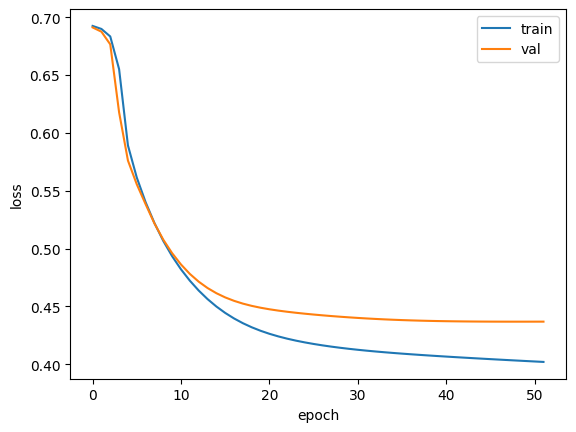

In [6]:
# 모델 컴파일, 학습
# batch_size, epoch 는 동일

rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model.compile(optimizer=rmsprop, loss='binary_crossentropy',
              metrics=['accuracy'])


checkpoint_cb = keras.callbacks.ModelCheckpoint(
    os.path.join(base_path, 'best-lstm-model.keras'),
    save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)

history = model.fit(train_seq, train_target, epochs=100, batch_size=64,
                    validation_data=(val_seq, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])


print('🟨 best_epoch: ', early_stopping_cb.best_epoch)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# ■ 순환 층에 드롭아웃 적용

In [ ]:
# 완전연결신경망과 CNN 에서는 Dropout 클래스를 사용해서 dropout 을 적용했었다
# 순환층은 '자체적으로 dropout 기능을 제공'

# SimpleRNN, LSTM 클래스에 제공하는 2개의 dropout= 매개변수
#   dropout= : 셀의 '입력'에 dropout 적용
#   recurrent_dropout= : 순환되는 '은닉상태'에 dropout 적용
#                        ※ recurrent_dropout 는 GPU를 통한 훈련 못함..

#  아래 예제에선 dropout= 만 사용함..

In [7]:
set_seed(42)
model = keras.Sequential(name="dropout_model")
model.add(keras.layers.Input(shape=(max_len,))) # (100,)
model.add(keras.layers.Embedding(500, 16))
model.add(keras.layers.LSTM(8, dropout=0.3))  # dropout 30%
model.add(keras.layers.Dense(1, activation='sigmoid'))

## 훈련🕒

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5243 - loss: 0.6926 - val_accuracy: 0.5822 - val_loss: 0.6915
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5724 - loss: 0.6905 - val_accuracy: 0.6132 - val_loss: 0.6887
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6119 - loss: 0.6861 - val_accuracy: 0.6472 - val_loss: 0.6818
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6540 - loss: 0.6719 - val_accuracy: 0.6948 - val_loss: 0.6517
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6944 - loss: 0.6183 - val_accuracy: 0.7168 - val_loss: 0.5888
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7179 - loss: 0.5801 - val_accuracy: 0.7316 - val_loss: 0.5663
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7362 - loss: 0.5571 - val_accuracy: 0.7452 - val_loss: 0.5449
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7523 - loss: 0.5352 - val_accu

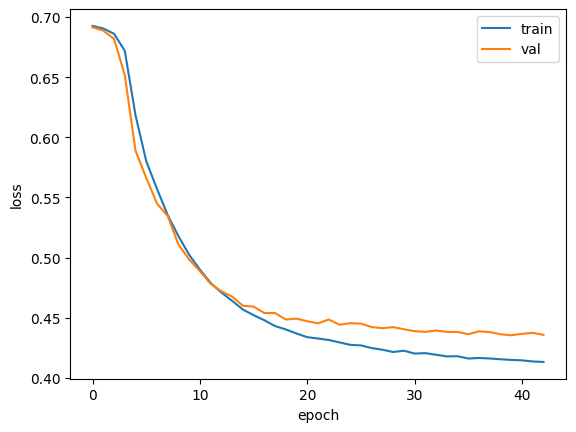

In [8]:
# 이전과 동일한 조건으로 훈련해보자 (저장 파일명만 변경)
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model.compile(optimizer=rmsprop, loss='binary_crossentropy',
               metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    os.path.join(base_path, 'best-dropout-model.keras'),
    save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)

history = model.fit(train_seq, train_target, epochs=100, batch_size=64,
                     validation_data=(val_seq, val_target),
                     callbacks=[checkpoint_cb, early_stopping_cb])

print('🟨 best_epoch: ', early_stopping_cb.best_epoch)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# ■ 순환층 2개 연결하기
### 순환층 연결시 주의!
- 순환층의 은닉상태는 샘플의 마지막 스텝에 대한 은닉 상태만 다음층으로 전달한다
- 그러나, 순환층을 쌓게 되면 모든 순환층에는 순차 데이터가 필요하다.
- 따라서
    - 앞쪽의 순환층은 '모든 타임스텝'에 대한 은닉상태를 출력해야 하고,
    - 마지막 순환층만 '마지막 타임스텝의 은닉상태'를 출력해야 한다

※ ppt 설명 참조

<img src="https://www.dropbox.com/scl/fi/q7b6o7pn3nqr6d11usvpe/LSTM01.jpg?rlkey=0rdunfnq364sptgh56f2m2i2w&st=47m4n188&dl=1" width=700>

## return_sequences=True
모든 타임스텝에 대한 은닉상태 출력 (2차원 출력)

In [10]:
# keras의 순환층에서 '모든타임스텝의 은닉상태' 를 출력하려면 마지막을 제외한 모든 순환층에
# return_sequences=True 를 지정해준다
set_seed(42)

model = keras.Sequential(name="2RNN-model")
model.add(keras.layers.Input(shape=(max_len,)))  # (100,)
model.add(keras.layers.Embedding(500, 16))
model.add(keras.layers.LSTM(8, dropout=0.3, return_sequences=True))
model.add(keras.layers.LSTM(8, dropout=0.3))
model.add(keras.layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "2RNN-model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 100, 8)         │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 8)              │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,353 (36.54 KB)

 Trainable params: 9,353 (36.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
"""
│ lstm_4 (LSTM)                   │ (None, 100, 8)         │           800 │
  => 4gates x units x (units + inputs + 1)
  => 4 x 8 x (8 + 16 + 1) => 800


│ lstm_5 (LSTM)                   │ (None, 8)              │           544 │
  => 4gates x units x (units + inputs + 1)
  => 4 x 8 x (8 + 8 + 1) => 544

"""
None



## 훈련🕒

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5052 - loss: 0.6931 - val_accuracy: 0.4996 - val_loss: 0.6931
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5311 - loss: 0.6926 - val_accuracy: 0.5768 - val_loss: 0.6923
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5765 - loss: 0.6911 - val_accuracy: 0.6344 - val_loss: 0.6893
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6157 - loss: 0.6843 - val_accuracy: 0.6578 - val_loss: 0.6744
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6619 - loss: 0.6484 - val_accuracy: 0.6946 - val_loss: 0.6040
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7042 - loss: 0.5834 - val_accuracy: 0.7252 - val_loss: 0.5573
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7311 - loss: 0.5482 - val_accuracy: 0.7412 - val_loss: 0.5341
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7506 - loss: 0.5251 - 

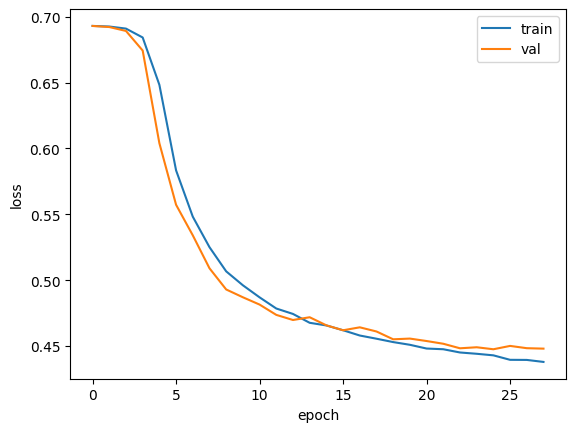

In [11]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model.compile(optimizer=rmsprop, loss='binary_crossentropy',
               metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint(
          os.path.join(base_path, 'best-2rnn-model.keras'),
          save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)

history = model.fit(train_seq, train_target, epochs=100, batch_size=64,
                     validation_data=(val_seq, val_target),
                     callbacks=[checkpoint_cb, early_stopping_cb])

print('🟨 best_epoch: ', early_stopping_cb.best_epoch)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()